#EDA del Dataset del Inventario

## Data Understanding & Exploratory Data Analysis (EDA)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

In [ ]:
# Cargar Datos
df = pd.read_csv('Grocery_Inventory_and_Sales_Dataset.csv')

In [ ]:
print('Dimension del dataframe')
print(df.shape)

Dimension del dataframe
(990, 16)


In [ ]:
df.head()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,15068 Scoville Court,62,25,Backordered


In [ ]:
# Revisión de estructura y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product_ID               990 non-null    object
 1   Product_Name             990 non-null    object
 2   Catagory                 989 non-null    object
 3   Supplier_ID              990 non-null    object
 4   Supplier_Name            990 non-null    object
 5   Stock_Quantity           990 non-null    int64 
 6   Reorder_Level            990 non-null    int64 
 7   Reorder_Quantity         990 non-null    int64 
 8   Unit_Price               990 non-null    object
 9   Date_Received            990 non-null    object
 10  Last_Order_Date          990 non-null    object
 11  Expiration_Date          990 non-null    object
 12  Warehouse_Location       990 non-null    object
 13  Sales_Volume             990 non-null    int64 
 14  Inventory_Turnover_Rate  990 non-null    i

In [ ]:
# Identificar valores nulos
print("Valores nulos en el dataset:")
print(df.isnull().sum())

# Identificar cantidad de duplicados
print(f"\nCantidad de filas duplicadas: {df.duplicated().sum()}")

Valores nulos en el dataset:
Product_ID                 0
Product_Name               0
Catagory                   1
Supplier_ID                0
Supplier_Name              0
Stock_Quantity             0
Reorder_Level              0
Reorder_Quantity           0
Unit_Price                 0
Date_Received              0
Last_Order_Date            0
Expiration_Date            0
Warehouse_Location         0
Sales_Volume               0
Inventory_Turnover_Rate    0
Status                     0
dtype: int64

Cantidad de filas duplicadas: 0


In [ ]:
# Resumen estadistico
df.describe()

,Stock_Quantity,Reorder_Level,Reorder_Quantity,Sales_Volume,Inventory_Turnover_Rate
count,990.000000,990.000000,990.000000,990.000000,990.000000
mean,55.609091,51.215152,51.913131,58.925253,50.150505
std,26.300775,29.095241,29.521059,23.002318,28.798954
min,10.000000,1.000000,1.000000,20.000000,1.000000
25%,33.000000,25.250000,25.000000,39.000000,25.000000
50%,56.000000,53.000000,54.000000,58.000000,50.000000
75%,79.000000,77.000000,77.000000,78.000000,74.750000
max,100.000000,100.000000,100.000000,100.000000,100.000000


### Gráficos

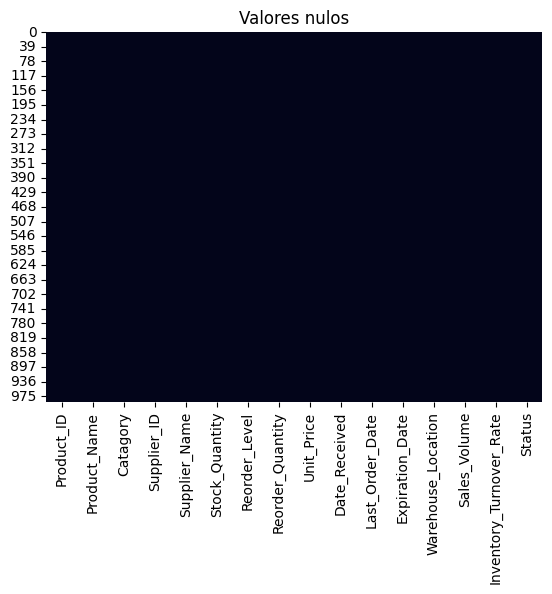

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title(f'Valores nulos')
plt.show()

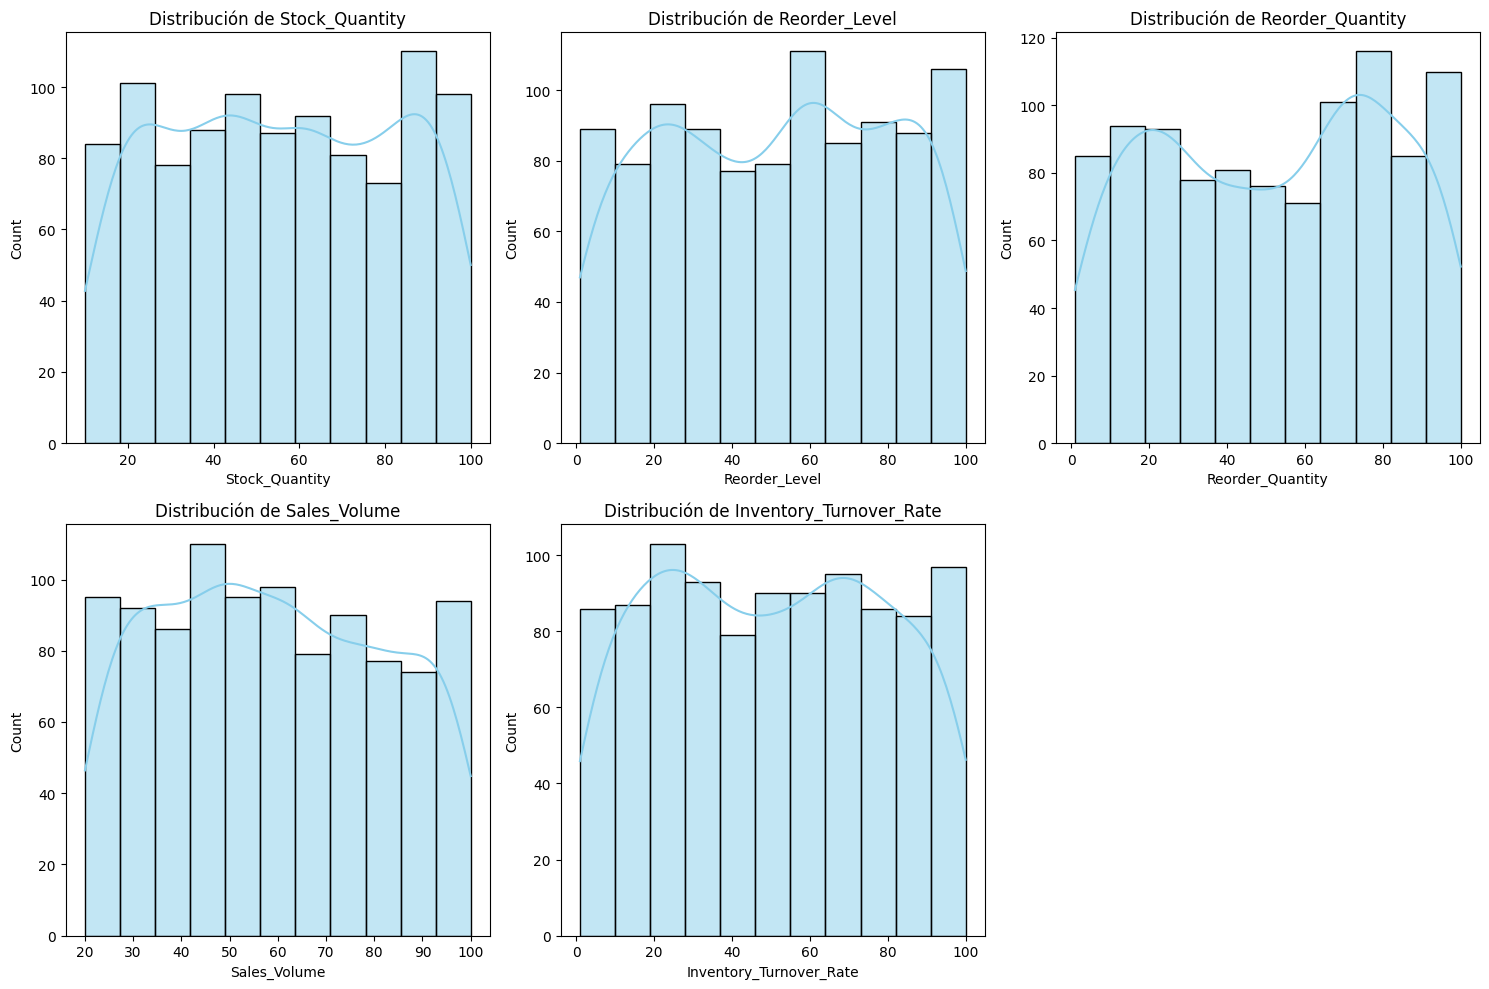

In [ ]:
# Distribución de las variables númericas
num_cols = ['Stock_Quantity', 'Reorder_Level', 'Reorder_Quantity', 'Sales_Volume', 'Inventory_Turnover_Rate']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
plt.tight_layout()

/tmp/ipykernel_31187/1617139247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Catagory', order=df['Catagory'].value_counts().index, palette='viridis')


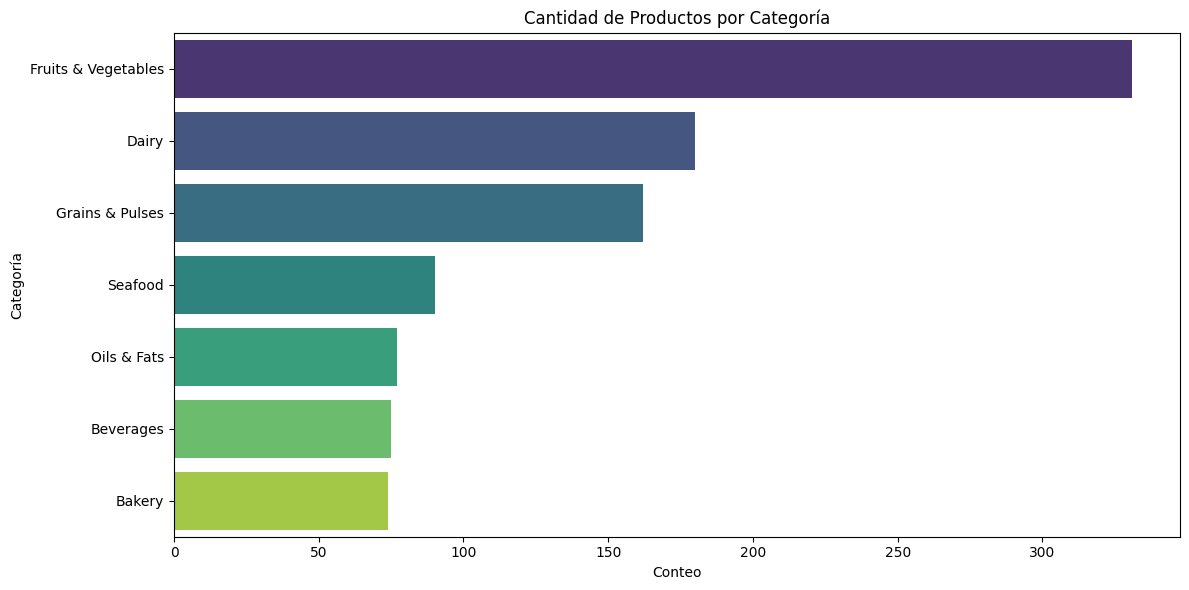

In [ ]:
# Cantidad de Productos por Categoría
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Catagory', order=df['Catagory'].value_counts().index, palette='viridis')
plt.title('Cantidad de Productos por Categoría')
plt.xlabel('Conteo')
plt.ylabel('Categoría')
plt.tight_layout()

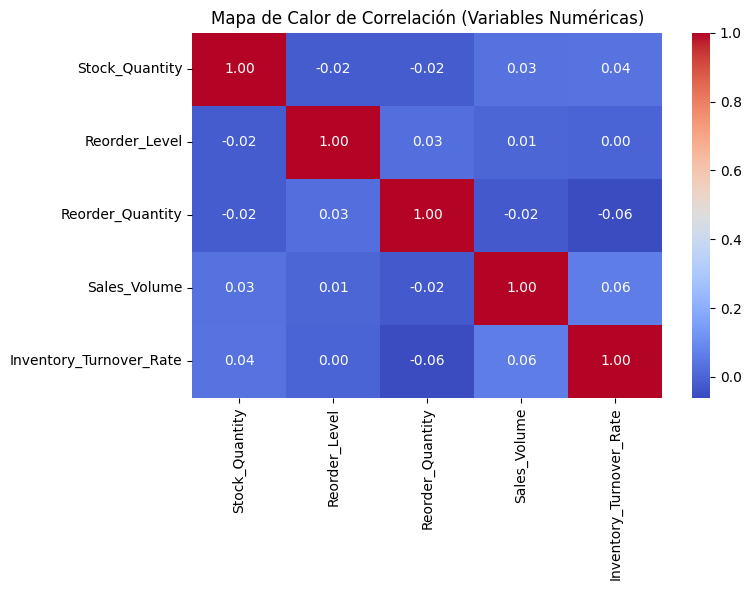

In [ ]:
# Correlación Heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlación (Variables Numéricas)')
plt.tight_layout()

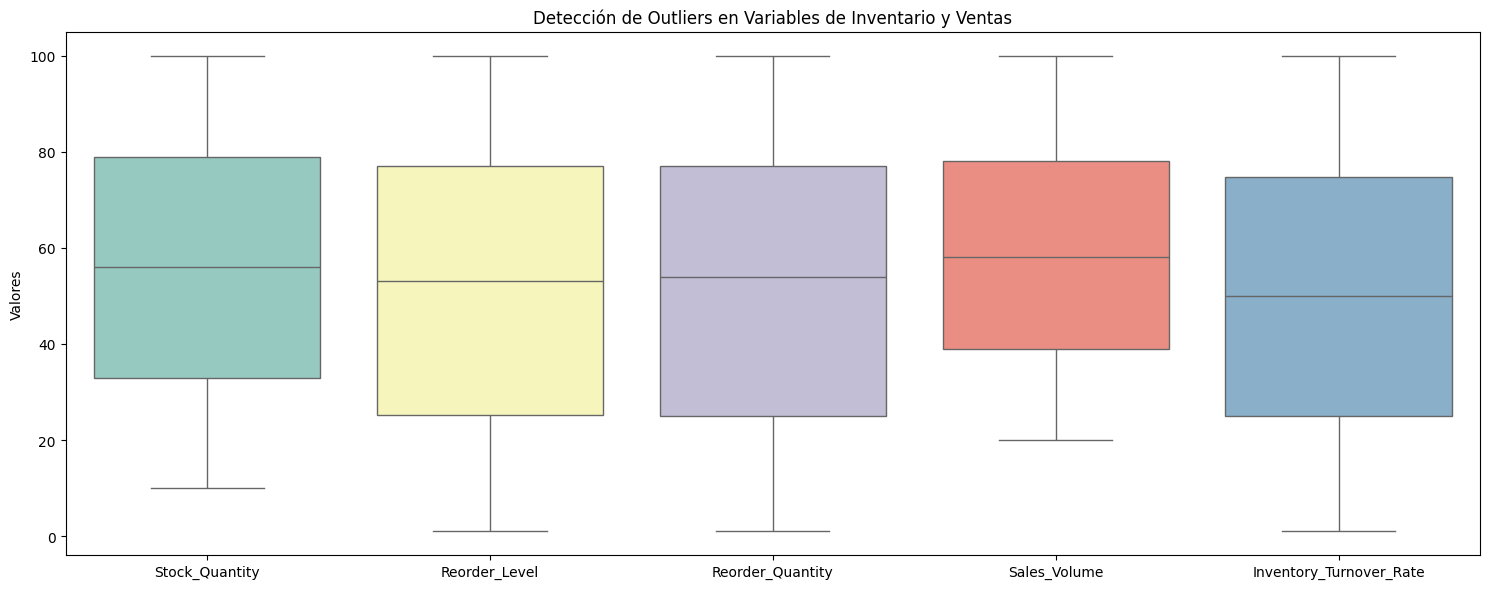

In [ ]:
# Boxplots de variables numéricas para detectar outliers
num_cols = ['Stock_Quantity', 'Reorder_Level', 'Reorder_Quantity', 'Sales_Volume', 'Inventory_Turnover_Rate']
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[num_cols], palette="Set3")
plt.title('Detección de Outliers en Variables de Inventario y Ventas')
plt.ylabel('Valores')
plt.tight_layout()

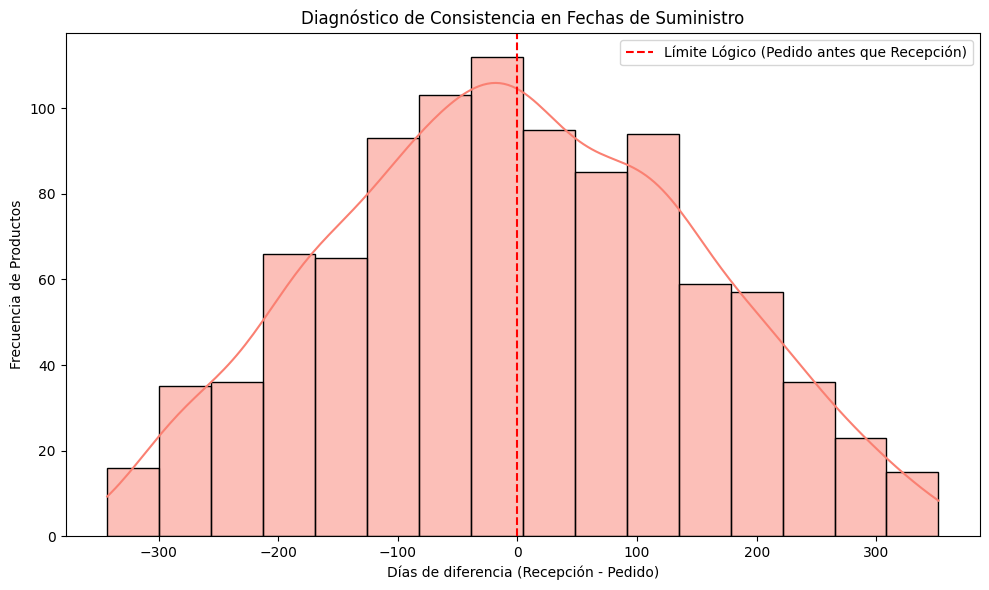

Total de registros analizados: 990
Cantidad de registros inconsistentes encontrados: 514
Porcentaje de error en data original: 51.92%


In [ ]:
df['Date_Received'] = pd.to_datetime(df['Date_Received'])
df['Last_Order_Date'] = pd.to_datetime(df['Last_Order_Date'])

# 2. Calcular el 'Lead Time' observado (Diferencia entre recepción y pedido)
df['Lead_Time_Check'] = (df['Date_Received'] - df['Last_Order_Date']).dt.days

plt.figure(figsize=(10, 6))
sns.histplot(df['Lead_Time_Check'], kde=True, color='salmon')
plt.axvline(0, color='red', linestyle='--', label='Límite Lógico (Pedido antes que Recepción)')
plt.title('Diagnóstico de Consistencia en Fechas de Suministro')
plt.xlabel('Días de diferencia (Recepción - Pedido)')
plt.ylabel('Frecuencia de Productos')
plt.legend()
plt.tight_layout()
plt.show()

inconsistencias = df[df['Lead_Time_Check'] < 0]
print(f"Total de registros analizados: {len(df)}")
print(f"Cantidad de registros inconsistentes encontrados: {len(inconsistencias)}")
print(f"Porcentaje de error en data original: {(len(inconsistencias)/len(df))*100:.2f}%")

In [ ]:
print("--- PRUEBA DE NORMALIDAD (Shapiro-Wilk) ---")
for col in num_cols:
    stat, p = shapiro(df[col].dropna())
    print(f'Variable: {col}')
    print(f'Estadístico=%.3f, p-valor=%.3f' % (stat, p))
    if p > 0.05:
        print('Interpretación: Probablemente Normal (No se rechaza H0)')
    else:
        print('Interpretación: No es Normal (Se rechaza H0)')
    print('-' * 30)

--- PRUEBA DE NORMALIDAD (Shapiro-Wilk) ---
Variable: Stock_Quantity
Estadístico=0.952, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------
Variable: Reorder_Level
Estadístico=0.952, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------
Variable: Reorder_Quantity
Estadístico=0.946, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------
Variable: Sales_Volume
Estadístico=0.957, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------
Variable: Inventory_Turnover_Rate
Estadístico=0.955, p-valor=0.000
Interpretación: No es Normal (Se rechaza H0)
------------------------------


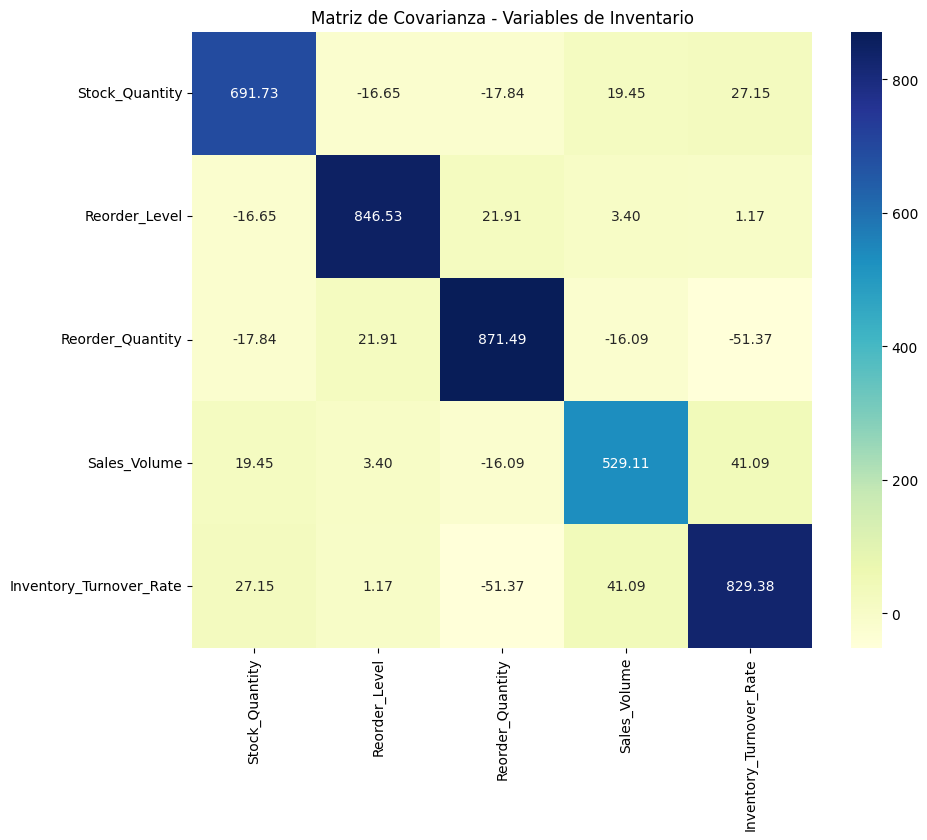

In [ ]:
# Cálculo de la Matriz de Covarianza
cov_matrix = df[num_cols].cov()

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Matriz de Covarianza - Variables de Inventario')
plt.show()

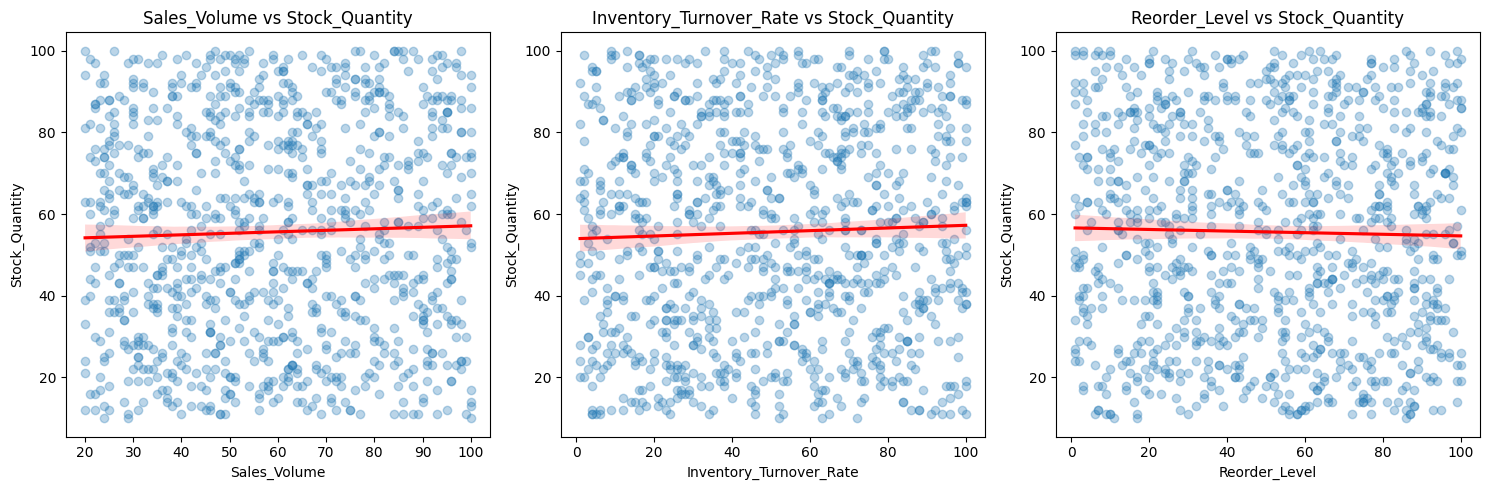

In [ ]:
# Variable objetivo: Stock_Quantity
variables_predictoras = ['Sales_Volume', 'Inventory_Turnover_Rate', 'Reorder_Level']

plt.figure(figsize=(15, 5))
for i, col in enumerate(variables_predictoras, 1):
    plt.subplot(1, 3, i)
    sns.regplot(data=df, x=col, y='Stock_Quantity', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'{col} vs Stock_Quantity')
plt.tight_layout()
plt.show()

#Data Preparation

In [ ]:
# Definimos las columnas que no aportan valor al dataset
# Lista de columnas a eliminar
columnas_irrelevantes = [
    'Product_ID',
    'Unit_Price',
    'Supplier_ID',
    'Supplier_Name',
    'Warehouse_Location'
]

# Eliminamos las columnas del DataFrame
df_clean = df.drop(columns=columnas_irrelevantes)
print(f"Columnas restantes: {len(df_clean.columns)}")
print(df_clean.columns.tolist())

df_clean.info()

Columnas restantes: 12
['Product_Name', 'Catagory', 'Stock_Quantity', 'Reorder_Level', 'Reorder_Quantity', 'Date_Received', 'Last_Order_Date', 'Expiration_Date', 'Sales_Volume', 'Inventory_Turnover_Rate', 'Status', 'Lead_Time_Check']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product_Name             990 non-null    object        
 1   Catagory                 989 non-null    object        
 2   Stock_Quantity           990 non-null    int64         
 3   Reorder_Level            990 non-null    int64         
 4   Reorder_Quantity         990 non-null    int64         
 5   Date_Received            990 non-null    datetime64[ns]
 6   Last_Order_Date          990 non-null    datetime64[ns]
 7   Expiration_Date          990 non-null    object        
 8   Sales_Volume             990 non-null    int64

In [ ]:
# Diccionario de nombres antiguos a nuevos
nuevos_nombres = {
    'Product_Name': 'Producto',
    'Catagory': 'Categoria',
    'Stock_Quantity': 'Stock_Actual',
    'Reorder_Level': 'Punto_Reorden',
    'Reorder_Quantity': 'Cantidad_Pedido',
    'Date_Received': 'Fecha_Recepcion',
    'Last_Order_Date': 'Ultimo_Pedido',
    'Expiration_Date': 'Fecha_Vencimiento',
    'Sales_Volume': 'Volumen_Consumo',
    'Inventory_Turnover_Rate': 'Tasa_Rotacion',
    'Status': 'Estado'
}

# Renombrar columnas
df_clean = df_clean.rename(columns=nuevos_nombres)

# Verificar el cambio
df_clean.head()

,Producto,Categoria,Stock_Actual,Punto_Reorden,Cantidad_Pedido,Fecha_Recepcion,Ultimo_Pedido,Fecha_Vencimiento,Volumen_Consumo,Tasa_Rotacion,Estado,Lead_Time_Check
0,Sushi Rice,Grains & Pulses,22,72,70,2024-08-16,2024-06-29,9/19/2024,32,19,Discontinued,48
1,Arabica Coffee,Beverages,45,77,2,2024-11-01,2024-05-29,5/8/2024,85,1,Discontinued,156
2,Black Rice,Grains & Pulses,30,38,83,2024-08-03,2024-06-10,9/22/2024,31,34,Backordered,54
3,Long Grain Rice,Grains & Pulses,12,59,62,2024-12-08,2025-02-19,4/17/2024,95,99,Active,-73
4,Plum,Fruits & Vegetables,37,30,74,2024-07-03,2024-10-11,10/5/2024,62,25,Backordered,-100


In [ ]:
# Imputar el valor nulo en Categoria
df_clean['Categoria'] = df_clean['Categoria'].fillna('Otros')

# Convertir columnas a formato datetime
fechas = ['Fecha_Recepcion', 'Ultimo_Pedido', 'Fecha_Vencimiento']
for col in fechas:
    df_clean[col] = pd.to_datetime(df_clean[col])

# Verificar que no haya nulos nuevos tras la conversión
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Producto           990 non-null    object        
 1   Categoria          990 non-null    object        
 2   Stock_Actual       990 non-null    int64         
 3   Punto_Reorden      990 non-null    int64         
 4   Cantidad_Pedido    990 non-null    int64         
 5   Fecha_Recepcion    990 non-null    datetime64[ns]
 6   Ultimo_Pedido      990 non-null    datetime64[ns]
 7   Fecha_Vencimiento  990 non-null    datetime64[ns]
 8   Volumen_Consumo    990 non-null    int64         
 9   Tasa_Rotacion      990 non-null    int64         
 10  Estado             990 non-null    object        
 11  Lead_Time_Check    990 non-null    int64         
dtypes: datetime64[ns](3), int64(6), object(3)
memory usage: 92.9+ KB


In [ ]:
def clasificar_vencimiento(dias):
    if dias < 0: return 'Vencido'
    if dias <= 15: return 'Crítico (15 días)'
    if dias <= 30: return 'Próximo (30 días)'
    return 'Seguro'

# Sumar 2 años a todas las columnas de fecha para que sea coherente al 2026
for col in ['Fecha_Recepcion', 'Ultimo_Pedido', 'Fecha_Vencimiento']:
    df_clean[col] = df_clean[col] + pd.Timedelta(days=730)

# Corregir la lógica de Pedido vs Recepción
# Definimos que el "Ultimo_Pedido" ocurrió siempre 7 días antes de la "Fecha_Recepcion"
df_clean['Ultimo_Pedido'] = df_clean['Fecha_Recepcion'] - pd.Timedelta(days=7)

# Recalcular los días para el vencimiento basándonos en hoy (Abril 2026)
fecha_hoy = pd.to_datetime('2026-04-29')
df_clean['Dias_para_Vencimiento'] = (df_clean['Fecha_Vencimiento'] - fecha_hoy).dt.days

# Actualizar el Estado de Vencimiento con los nuevos datos
df_clean['Estado_Vencimiento'] = df_clean['Dias_para_Vencimiento'].apply(clasificar_vencimiento)

df_clean[['Producto', 'Ultimo_Pedido', 'Fecha_Recepcion', 'Fecha_Vencimiento', 'Estado_Vencimiento']].head()

,Producto,Ultimo_Pedido,Fecha_Recepcion,Fecha_Vencimiento,Estado_Vencimiento
0,Sushi Rice,2026-08-09,2026-08-16,2026-09-19,Seguro
1,Arabica Coffee,2026-10-25,2026-11-01,2026-05-08,Crítico (15 días)
2,Black Rice,2026-07-27,2026-08-03,2026-09-22,Seguro
3,Long Grain Rice,2026-12-01,2026-12-08,2026-04-17,Vencido
4,Plum,2026-06-26,2026-07-03,2026-10-05,Seguro


In [ ]:
# --- 30 INSUMOS MÉDICOS CRÍTICOS ---
insumos_medicos = [
    ('Metotrexato 500mg', 'Oncológicos'), ('Ciclofosfamida 1g', 'Oncológicos'),
    ('Vincristina 1mg', 'Oncológicos'), ('Doxorrubicina 50mg', 'Oncológicos'),
    ('Ondansetrón 8mg', 'Antieméticos'), ('Dexametasona 4mg', 'Antieméticos'),
    ('Suero Fisiológico 500ml', 'Soporte'), ('Dextrosa al 5%', 'Soporte'),
    ('Cloruro de Potasio 20%', 'Soporte'), ('Catéter Endovenoso 24G', 'Insumos'),
    ('Catéter Port-a-Cath', 'Insumos'), ('Jeringa 5ml', 'Insumos'),
    ('Equipo de Venoclisis', 'Insumos'), ('Llave de 3 vías', 'Insumos'),
    ('Pediasure Plus 200ml', 'Nutrición'), ('Fórmula Polimérica', 'Nutrición'),
    ('Espesante de Alimentos', 'Nutrición'), ('Mascarilla N95 Pediátrica', 'Higiene'),
    ('Alcohol en Gel 70%', 'Higiene'), ('Guantes Estériles', 'Higiene'),
    ('Jabón Clorhexidina', 'Higiene'), ('Tubo Vacutainer (Rojo)', 'Laboratorio'),
    ('Tubo Vacutainer (Lila)', 'Laboratorio'), ('Placas de Rayos X', 'Imágenes'),
    ('Crema de Hidrocortisona', 'Tópicos'), ('Gasas Estériles', 'Curación'),
    ('Esparadrapo Micropore', 'Curación'), ('Paracetamol Jarabe', 'Analgesicos'),
    ('Ibuprofeno Pediátrico', 'Analgesicos'), ('Ceftriaxona 1g', 'Antibióticos')
]

# --- GENERACIÓN DE 500 FILAS SINTÉTICAS ---
np.random.seed(42)
data_medica = []
fecha_hoy = pd.to_datetime('2026-04-29')

for i in range(500):
    producto, categoria = insumos_medicos[np.random.randint(len(insumos_medicos))]

    # Lógica de Criticidad: Los Oncológicos y Soporte tienen stock más volátil
    if categoria in ['Oncológicos', 'Soporte']:
        stock_actual = np.random.randint(5, 60)
        vol_consumo = np.random.randint(40, 110)
    else:
        stock_actual = np.random.randint(30, 150)
        vol_consumo = np.random.randint(10, 70)

    punto_reorden = int(vol_consumo * 0.6)

    # Fechas 2026 con lógica corregida (Pedido siempre antes que Recepción)
    fecha_rec = pd.to_datetime('2026-01-10') + pd.Timedelta(days=np.random.randint(0, 120))
    lead_time = np.random.randint(3, 12)
    ultimo_pedido = fecha_rec - pd.Timedelta(days=lead_time)
    fecha_vencimiento = fecha_rec + pd.Timedelta(days=np.random.randint(180, 720))
    dias_venc = (fecha_vencimiento - fecha_hoy).dt.days if isinstance(fecha_vencimiento, pd.Series) else (fecha_vencimiento - fecha_hoy).days

    data_medica.append({
        'Producto': producto,
        'Categoria': categoria,
        'Stock_Actual': stock_actual,
        'Punto_Reorden': punto_reorden,
        'Cantidad_Pedido': np.random.randint(50, 200),
        'Fecha_Recepcion': fecha_rec,
        'Ultimo_Pedido': ultimo_pedido,
        'Fecha_Vencimiento': fecha_vencimiento,
        'Volumen_Consumo': vol_consumo,
        'Tasa_Rotacion': round(vol_consumo / (stock_actual + 1), 2),
        'Estado': 'Active',
        'Dias_para_Vencimiento': dias_venc,
        'Estado_Vencimiento': clasificar_vencimiento(dias_venc)
    })

# Crear DataFrame sintético
df_medico_sintetico = pd.DataFrame(data_medica)

# Concatenar con el dataset de abarrotes limpio
df_final = pd.concat([df_clean, df_medico_sintetico], ignore_index=True)
print(f"Dataset Unificado ALDIMI: {len(df_final)} registros.")
print(f"Columnas finales: {df_final.columns.tolist()}")

Dataset Unificado ALDIMI: 1490 registros.
Columnas finales: ['Producto', 'Categoria', 'Stock_Actual', 'Punto_Reorden', 'Cantidad_Pedido', 'Fecha_Recepcion', 'Ultimo_Pedido', 'Fecha_Vencimiento', 'Volumen_Consumo', 'Tasa_Rotacion', 'Estado', 'Lead_Time_Check', 'Dias_para_Vencimiento', 'Estado_Vencimiento']


In [ ]:
# Exportación csv del dataset final
nombre_archivo = 'inventario_limpio.csv'
df_final.to_csv(nombre_archivo, index=False)